#  Análise de Grafos — Documentação e Exemplos

Este notebook documenta e explica as implementações presentes nos arquivos `graph.py` e `main.py`.  
O projeto implementa uma estrutura de grafo não-direcionado com suporte a análise de distribuição de graus e ajuste de **lei de potência** (*power law*), técnicas comuns na análise de redes complexas.

---

##  Importações

As bibliotecas utilizadas são:

- **`algs4.bag`**: Estrutura de dados *Bag* (sacola), usada como lista de adjacência — permite armazenar múltiplos elementos sem ordem definida.
- **`networkx`**: Biblioteca para criação e visualização de grafos.
- **`matplotlib`**: Geração de gráficos e histogramas.
- **`numpy`**: Operações numéricas, especialmente para o ajuste de curvas no espaço log-log.
- **`scipy.optimize.curve_fit`**: Ajuste de curvas (importado, mas o ajuste principal é feito com `np.polyfit`).
- **`collections.Counter`**: Contagem de frequências dos graus dos vértices.

In [1]:
from algs4.bag import Bag
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from collections import Counter

---

##  Classe `Graph` — Estrutura Principal

A classe `Graph` representa um **grafo não-direcionado** com lista de adjacência.  
Internamente, usa um dicionário `map` para associar **valores reais dos nós** (ex: IDs de usuários) às **posições internas** na lista de adjacência `adj`.

Isso permite trabalhar com grafos cujos vértices não são necessariamente inteiros sequenciais a partir de 0.

### `__init__(self, v)`
Inicializa o grafo com:
- `V`: número de vértices
- `E`: número de arestas (começa em 0)
- `map`: dicionário `{valor_do_nó → posição_interna}`
- `adj`: lista de `Bag`s representando a lista de adjacência

In [2]:
class Graph:

    def __init__(self, v):
        self.V = v
        self.E = 0
        self.map = {}
        self.adj = []

---

##  Mapeamento de Nós

Como os IDs dos nós podem ser números arbitrários (ex: `1024`, `5890`), é necessário mapeá-los para posições internas `0, 1, 2, ...` na lista de adjacência.

### `add_mapping(self, node_value)`
Registra um novo nó no dicionário `map` e cria uma `Bag` vazia na lista de adjacência para ele.

### `get_position(self, node_value)`
Retorna a posição interna de um nó a partir do seu valor real.

### `get_value(self, node_position)`
Operação inversa: dado uma posição interna, retorna o valor real do nó.

In [3]:
    def add_mapping(self, node_value: int) -> None:
        self.map[node_value] = len(self.adj)
        self.adj.append(Bag())

    def get_position(self, node_value: int) -> int:
        return self.map[node_value]

    def get_value(self, node_position: int) -> int:
        for key, value in self.map.items():
            if value == node_position:
                return key

---

##  Adição de Arestas

### `add_edge(self, v, w, directed=False)`

Adiciona uma aresta entre os vértices `v` e `w`.

**Funcionamento:**
1. Se `v` ou `w` ainda não existem no grafo, chama `add_mapping` automaticamente.
2. Se `directed=True`, verifica se a aresta já existe (evita duplicatas em grafos dirigidos).
3. Adiciona `w` na lista de adjacência de `v` **e** `v` na lista de adjacência de `w` (grafo não-direcionado → aresta bidirecional).
4. Incrementa o contador de arestas `E`.



In [4]:
    def add_edge(self, v, w, directed: bool = False):
        if v not in self.map:
            self.add_mapping(v)
        if w not in self.map:
            self.add_mapping(w)
        if directed:
            if w in self.adj[self.get_position(v)]:
                return
        v_position = self.get_position(v)
        w_position = self.get_position(w)
        self.adj[v_position].add(w)
        self.adj[w_position].add(v)
        self.E += 1

---

##  Métricas Básicas do Grafo

### `degree(self, v, from_value=True)`
Retorna o **grau** de um vértice — ou seja, o número de vizinhos (arestas conectadas a ele).  
Se `from_value=True`, `v` é o valor real do nó; se `False`, é a posição interna.

### `density(self)`
Calcula a **densidade** do grafo:
$$\text{densidade} = \frac{2E}{V(V-1)}$$
Varia entre 0 (nenhuma aresta) e 1 (grafo completo).  
Densidade ≥ 0.8 → **Denso** | Densidade < 0.8 → **Esparso**

### `min_degree()` / `max_degree()`
Retornam o menor e o maior grau entre todos os vértices do grafo.

In [5]:
    def degree(self, v, from_value: bool = True) -> int:
        v_position = self.get_position(v) if from_value else v
        return self.adj[v_position].size()

    def density(self):
        return (2 * self.E) / (self.V * (self.V - 1))

    def min_degree(self) -> int:
        return min(self.degree(v) for v in self.map.keys())

    def max_degree(self) -> int:
        return max(self.degree(v) for v in self.map.keys())

---

## Carregamento de Dados

### `add_node_from_file(self, file_path='data.txt')`

Lê arestas a partir de um arquivo de texto.  
**Formato esperado:** cada linha contém dois inteiros separados por espaço ou tab, representando uma aresta:
```
1   2
1   3
2   4
```
Para cada linha, chama `add_edge(origem, destino)`.

In [6]:
    def add_node_from_file(self, file_path: str = "data.txt") -> None:
        with open(file_path, 'r') as file:
            linhas = file.readlines()
        for linha in linhas:
            linha_tratada = linha.replace("\t", " ").replace("\n", "").split(" ")
            no_origem, no_destino = map(int, linha_tratada)
            self.add_edge(no_origem, no_destino)

---

## Funções de Impressão e Debug

### `__str__(self)`
Representação textual do grafo: exibe número de vértices, arestas e a lista de adjacência completa.

### `print_mapping(self, len=10)`
Imprime os primeiros `len` mapeamentos `valor_real → posição_interna`.

### `print_adjacency_list(self, len=10)`
Imprime um resumo do grafo (ordem, tamanho, densidade, grau mínimo e máximo) e os primeiros `len` vértices com suas adjacências e grau individual.

### `print_degree_for_value(self, node_value)`
Imprime o grau de um vértice específico dado pelo seu valor real.

In [7]:
    def print_mapping(self, len: int = 10) -> None:
        for i, (key, value) in enumerate(self.map.items()):
            if i >= len:
                break
            print(f"{key} -> {value}")

    def print_adjacency_list(self, len: int = 10) -> None:
        print(f"Vértices(Ordem): {self.V}; Arestas(Tamanho): {self.E}; Densidade: {self.density():.4f} "
              f"({'Denso' if self.density() >= 0.8 else 'Esparso'}); "
              f"Grau mínimo: {self.min_degree()}; Grau máximo: {self.max_degree()}")
        for i in range(min(len, self.V)):
            print(f"{self.get_value(i)}: {self.adj[i]} - Grau: {self.degree(self.get_value(i))}")

    def print_degree_for_value(self, node_value: int) -> None:
        degree = self.degree(node_value)
        print(f"Grau do vértice {node_value}: {degree}")

---

## Visualização do Grafo

### `save_graph(self, len=10, save_path='graph.png')`

Gera e salva uma imagem do grafo usando **NetworkX** + **Matplotlib**.  
Por padrão, visualiza apenas os primeiros `len` vértices (útil para grafos grandes onde plotar tudo seria inviável).  
Os nós são exibidos em azul claro com rótulos.

In [8]:
    def save_graph(self, len: int = 10, save_path: str = "graph.png") -> None:
        G = nx.Graph()
        for v, neighbors in enumerate(self.adj):
            if v >= len:
                break
            for w in neighbors:
                G.add_edge(self.get_value(v), w)
        plt.figure(figsize=(10, 8))
        nx.draw(G, with_labels=True, node_color='lightblue', font_weight='bold')
        plt.savefig(save_path)

---

## Histograma de Graus

### `save_histogram_degree(self, save_path='histogram.png')`

Gera e salva um **histograma** com a distribuição de graus de todos os vértices do grafo.  
O eixo X representa o grau e o eixo Y a frequência (quantos vértices têm aquele grau).  

Esse gráfico é um primeiro passo para identificar padrões como a **lei de potência**: se a maioria dos nós tem poucos vizinhos e pouquíssimos nós têm muitos (os chamados *hubs*), o histograma terá uma cauda longa à direita.

In [9]:
    def save_histogram_degree(self, save_path: str = "histogram.png") -> None:
        degrees = [self.degree(v) for v in self.map.keys()]
        plt.figure(figsize=(10, 6))
        plt.hist(degrees, bins=range(max(degrees) + 1), color='lightblue', edgecolor='black')
        plt.title('Histograma de Graus dos Vértices')
        plt.xlabel('Grau')
        plt.ylabel('Frequência')
        plt.savefig(save_path)

---

## Distribuição de Graus e Lei de Potência

### `get_degree_distribution(self)`
Retorna um dicionário `{grau: frequência}` com a contagem de quantos vértices possuem cada grau.

### `fit_power_law(self)`

Ajusta uma **lei de potência** à distribuição de graus:
$$P(k) \sim C \cdot k^{-\gamma}$$

**Passo a passo:**
1. Obtém a distribuição de graus e normaliza para probabilidade.
2. Filtra graus e probabilidades zero.
3. Aplica **regressão linear no espaço log-log** (lineariza a lei de potência):
   $$\log P(k) = \log C - \gamma \cdot \log k$$
4. Usa `np.polyfit` para encontrar o coeficiente angular (`-γ`) e o intercepto (`log C`).
5. Calcula o **R²** (coeficiente de determinação) para avaliar a qualidade do ajuste.

**Retorna:** dicionário com `gamma`, `C`, `k_min`, `r_squared` e os dados filtrados.

In [10]:
    def get_degree_distribution(self):
        degrees = [self.degree(v) for v in self.map.keys()]
        return dict(Counter(degrees))

    def fit_power_law(self):
        degree_dist = self.get_degree_distribution()
        degrees = np.array(sorted(degree_dist.keys()))
        frequencies = np.array([degree_dist[k] for k in degrees])
        probabilities = frequencies / frequencies.sum()

        mask = (probabilities > 0) & (degrees > 0)
        degrees_filtered = degrees[mask]
        probabilities_filtered = probabilities[mask]

        log_k = np.log(degrees_filtered)
        log_p = np.log(probabilities_filtered)

        coeffs = np.polyfit(log_k, log_p, 1)
        gamma = -coeffs[0]
        log_C = coeffs[1]
        C = np.exp(log_C)

        log_p_pred = log_C - gamma * log_k
        ss_res = np.sum((log_p - log_p_pred)**2)
        ss_tot = np.sum((log_p - log_p.mean())**2)
        r_squared = 1 - (ss_res / ss_tot)

        k_min = degrees_filtered.min()

        return {
            'gamma': gamma, 'C': C, 'k_min': k_min,
            'r_squared': r_squared,
            'degrees': degrees_filtered,
            'probabilities': probabilities_filtered,
        }

---

## Gráfico Log-Log com Ajuste

### `save_power_law_plot(self, save_path='power_law_fit.png')`

Gera o gráfico **log-log** da distribuição de graus com a curva de lei de potência ajustada sobreposta.  

- Pontos azuis = dados observados  
- Linha vermelha = curva $P(k) = C \cdot k^{-\gamma}$ ajustada  
- Anotação no canto com a interpretação do γ  

Se os dados formarem uma linha reta no gráfico log-log, isso é forte evidência de comportamento de lei de potência — característico de **redes livre de escala** (*scale-free networks*) como a internet, redes sociais e redes metabólicas.

In [11]:
    def save_power_law_plot(self, save_path: str = "power_law_fit.png") -> dict:
        fit_results = self.fit_power_law()
        gamma = fit_results['gamma']
        C = fit_results['C']
        r_squared = fit_results['r_squared']
        degrees = fit_results['degrees']
        probabilities = fit_results['probabilities']

        plt.figure(figsize=(10, 7))
        plt.loglog(degrees, probabilities, 'bo', alpha=0.6, markersize=8, label='Dados observados')

        k_fit = np.linspace(degrees.min(), degrees.max(), 100)
        p_fit = C * k_fit**(-gamma)
        plt.loglog(k_fit, p_fit, 'r-', linewidth=2,
                   label=f'Lei de potência: $P(k) \\sim k^{{-\\gamma}}$\n$\\gamma = {gamma:.3f}$\n$R^2 = {r_squared:.4f}$')

        plt.xlabel('Grau (k)', fontsize=12)
        plt.ylabel('P(k)', fontsize=12)
        plt.title('Distribuição de Graus - Ajuste de Lei de Potência', fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3, which='both')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

        return fit_results

---

## Interpretação do Expoente γ

### `interpret_gamma(self, gamma)`

Interpreta o valor do expoente γ segundo a literatura de redes complexas:

| Faixa de γ | Interpretação |
|---|---|
| γ < 2 | Rede extremamente concentrada em hubs |
| 2 ≤ γ < 3 | Maioria dos nós com poucas conexões, hubs dominantes (*scale-free* típico) |
| 3 ≤ γ < 4 | Hubs presentes mas menos dominantes |
| γ ≥ 4 | Sem hubs bem definidos, comportamento próximo a redes aleatórias |

Redes reais como a Web, redes de citação científica e redes metabólicas tipicamente apresentam **2 ≤ γ < 3**.

### `print_power_law_analysis(self)`
Imprime um relatório textual completo do ajuste, incluindo γ, R², k_min, interpretação e qualidade do ajuste.

In [12]:
    def interpret_gamma(self, gamma: float) -> str:
        if gamma < 2:
            return f" γ < 2: Rede extremamente concentrada em hubs."
        elif 2 <= gamma < 3:
            return f" 2 ≤ γ < 3: A maioria dos nós tem poucas conexões"
        elif 3 <= gamma < 4:
            return f"3 ≤ γ < 4: Rede com hubs menos dominantes, mas ainda presentes."
        else:
            return f"γ ≥ 4: Rede sem hubs bem definidos, com comportamento semelhante a uma rede aleatória."

    def print_power_law_analysis(self):
        fit_results = self.fit_power_law()
        gamma = fit_results['gamma']
        r_squared = fit_results['r_squared']
        k_min = fit_results['k_min']

        print("=" * 60)
        print("ANÁLISE DE LEI DE POTÊNCIA")
        print("=" * 60)
        print(f"Expoente (γ): {gamma:.4f}")
        print(f"Coeficiente de determinação (R²): {r_squared:.4f}")
        print(f"Grau mínimo considerado (k_min): {k_min}")
        print(f"Interpretação do γ: {self.interpret_gamma(gamma)}")

        if r_squared >= 0.9:
            print("Forte indício de lei de potência (R² alto)")
        elif r_squared >= 0.8:
            print("Indício razoável de lei de potência")
        elif r_squared >= 0.7:
            print("Possível comportamento de lei de potência")
        else:
            print("Os dados não sugerem claramente uma lei de potência")

---

## `main.py` — Execução Principal

O arquivo `main.py` orquestra todas as funcionalidades acima para analisar um grafo real carregado de `data.txt`.

**Constantes utilizadas:**
- `NUMERO_VERTICES = 5242` → número de nós do grafo
- `NUMERO_ARESTAS = 28980` → número de arestas esperadas

**Fluxo de execução:**
1. Cria o grafo com `Graph(5242)`
2. Carrega as arestas do arquivo `data.txt`
3. Imprime o resumo da lista de adjacência (primeiros 10 vértices)
4. Salva imagem visual dos primeiros 10 vértices em `graph_10.png`
5. Salva o histograma de graus em `histogram.png`
6. Gera o gráfico log-log com ajuste de lei de potência em `power_law_fit.png`
7. Imprime o relatório de análise no terminal
8. Salva os resultados numéricos em `power_law_results.txt`

57960 27473322
57960 27473322
Vértices(Ordem): 5242; Arestas(Tamanho): 28980; Densidade: 0.0021 (Esparso); Grau mínimo: 2; Grau máximo: 162
3466: 19607 18720 937 15931 8579 17038 5233 10310 19607 18720 17038 15931 10310 8579 5233 937 - Grau: 16
937: 18233 14924 8579 4135 3466 18233 4135 14924 8579 3466 - Grau: 10
5233: 10310 3466 10310 3466 - Grau: 4
8579: 19607 937 4135 19607 16258 4135 3466 937 16258 3466 - Grau: 10
10310: 14982 1854 24814 13056 24372 4583 23855 10841 16310 5233 9572 19640 24814 24372 23855 19640 16310 14982 13056 10841 9572 5233 4583 3466 1854 3466 - Grau: 26
15931: 19607 18720 24444 24009 23344 19865 19607 18720 18233 15959 14924 3466 18233 24444 15959 14924 23344 19865 24009 3466 - Grau: 20
17038: 20033 17389 16766 16858 19089 23429 24578 17113 7277 18408 21968 16770 24578 23429 21968 20033 19992 19089 18866 18408 17389 17113 16858 16770 16766 7277 7188 3466 896 896 19992 18866 7188 3466 - Grau: 34
18720: 19607 19607 15931 3466 15931 3466 - Grau: 6
19607: 18720 15

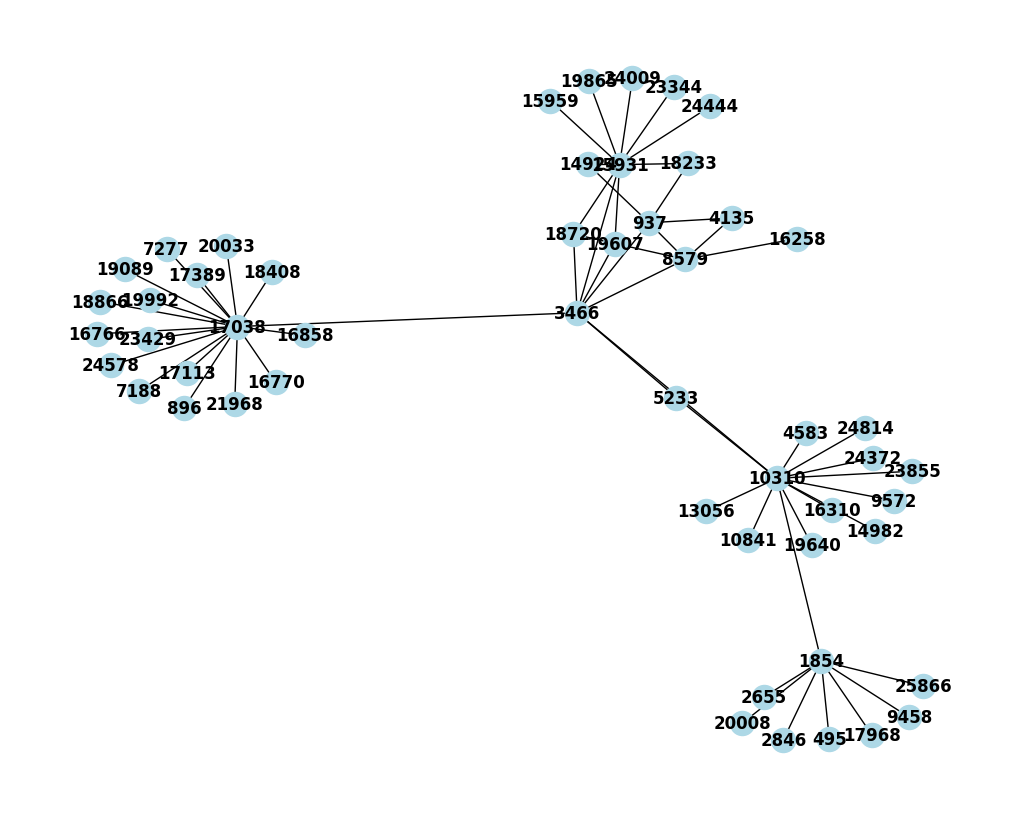

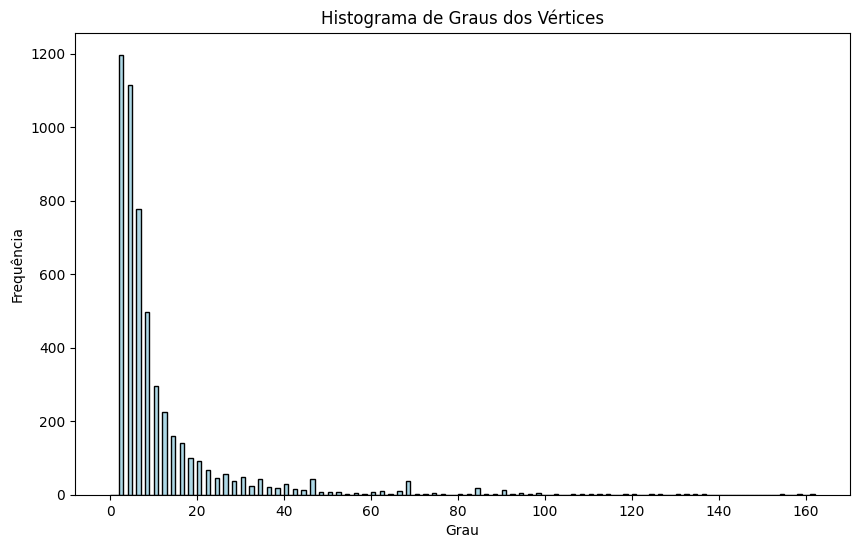

In [13]:
from graph import Graph

NUMERO_VERTICES = 5242
NUMERO_ARESTAS = 28980

if __name__ == "__main__":
    grafo = Graph(NUMERO_VERTICES)
    grafo.add_node_from_file("data.txt")
    grafo.print_adjacency_list()
    grafo.save_graph(save_path="graph_10.png")
    grafo.save_histogram_degree()

    fit_results = grafo.save_power_law_plot(save_path="power_law_fit.png")
    grafo.print_power_law_analysis()

    with open("power_law_results.txt", "w", encoding="utf-8") as f:
        f.write("RESULTADOS DO AJUSTE DE LEI DE POTÊNCIA\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Expoente (γ): {fit_results['gamma']:.4f}\n")
        f.write(f"Constante de normalização (C): {fit_results['C']:.6e}\n")
        f.write(f"Coeficiente de determinação (R²): {fit_results['r_squared']:.4f}\n")
        f.write(f"Grau mínimo considerado (k_min): {fit_results['k_min']}\n")
        f.write(f"\nInterpretação do expoente γ = {fit_results['gamma']:.4f}:\n")
        f.write(grafo.interpret_gamma(fit_results['gamma']) + "\n")

    print("✓ Gráfico salvo em: power_law_fit.png")
    print("✓ Resultados salvos em: power_law_results.txt")

---

## Referências

- [Barabási & Albert — Emergence of Scaling in Random Networks](https://www.science.org/doi/10.1126/science.286.5439.509)
- [Sole et al. — Network Motifs in Metabolic Networks (PNAS)](https://www.pnas.org/doi/10.1073/pnas.202301299)
- [DataCamp — Coefficient of Determination (R²)](https://www.datacamp.com/tutorial/coefficient-of-determination)
- [NetworkX Documentation](https://networkx.org/documentation/stable/)
- [algs4 Python port](https://github.com/itu-algorithms/itu.algs4)